# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

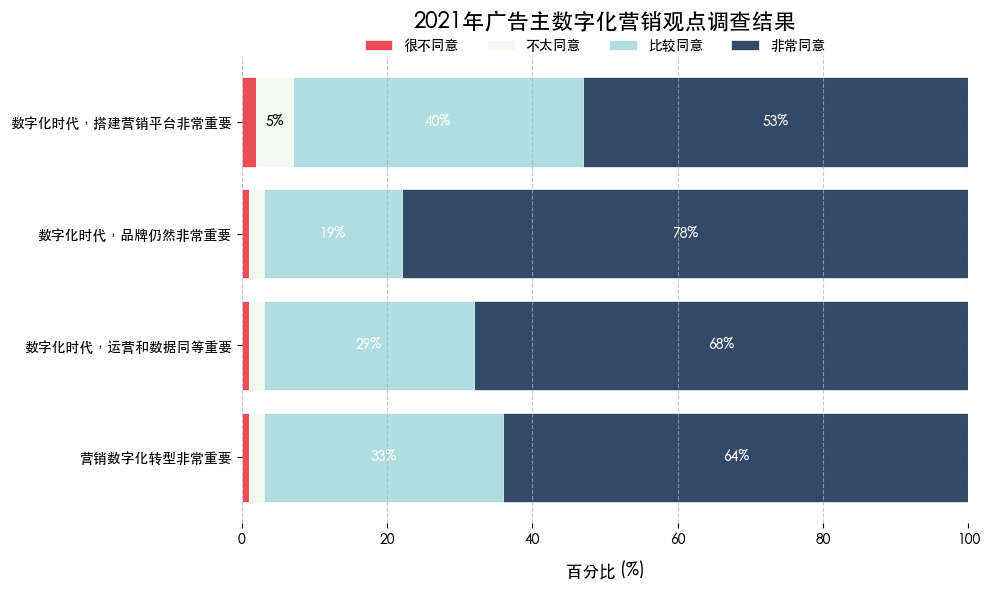

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ["营销数字化转型非常重要", "数字化时代，运营和数据同等重要", 
          "数字化时代，品牌仍然非常重要", "数字化时代，搭建营销平台非常重要"]
very_agree = np.array([64, 68, 78, 53])  # 非常同意占比
agree = np.array([33, 29, 19, 40])  # 比较同意占比
disagree = np.array([2, 2, 2, 5])  # 不太同意占比
strong_disagree = np.array([1, 1, 1, 2])  # 很不同意占比

# 颜色方案（使用更现代的配色）
colors = ['#E63946', '#F1FAEE', '#A8DADC', '#1D3557']  # 从红色到深蓝色的渐变

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 6))  # 调整画布大小

# 绘制横向堆积条形图
bottom = np.zeros(len(labels))
for i, (data, label, color) in enumerate(zip(
    [strong_disagree, disagree, agree, very_agree],
    ['很不同意', '不太同意', '比较同意', '非常同意'],
    colors
)):
    bars = ax.barh(labels, data, left=bottom, color=color, label=label, 
                  alpha=0.9, edgecolor='w', linewidth=0.5)
    
    # 在每个条形上标注百分比
    for bar, value in zip(bars, data):
        if value > 2:  # 只显示足够宽的条形上的文本
            ax.text(
                bar.get_x() + bar.get_width()/2, 
                bar.get_y() + bar.get_height()/2,
                f"{value}%", 
                ha='center', 
                va='center',
                color='black' if i < 2 else 'white',  # 根据背景色调整文本颜色
                fontweight='bold',
                fontsize=10
            )
    
    bottom += data

# 设置标题
ax.set_title('2021年广告主数字化营销观点调查结果', fontsize=16, fontweight='bold', pad=20)

# 设置标签
ax.set_xlabel('百分比 (%)', fontsize=12, labelpad=10)
# ax.set_ylabel('观点', fontsize=12, labelpad=10)  # 移除y轴标签

# 设置网格线
ax.grid(axis='x', linestyle='--', alpha=0.7)

# 设置x轴范围
ax.set_xlim(0, 100)

# 美化图例 - 放置在标题下方
fig.legend(loc='upper center', bbox_to_anchor=(0.6, 0.95), ncol=4, frameon=False, fontsize=10)

# 调整边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 调整布局，为图例腾出空间
plt.subplots_adjust(top=0.85)  # 减小顶部边距
plt.tight_layout()

# 显示图表
plt.show()    

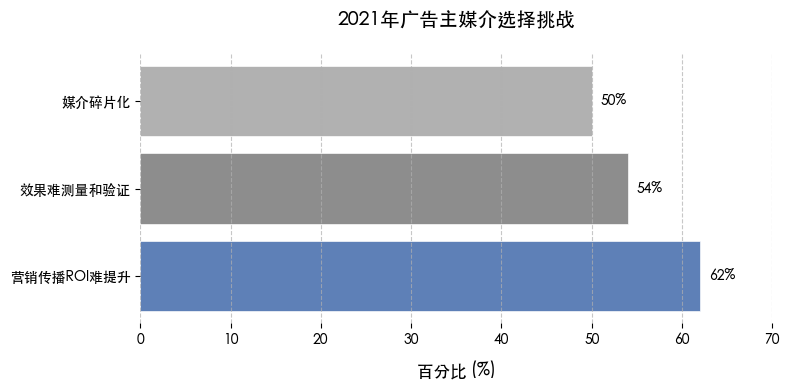

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 新图表对应的数据
labels = ["营销传播ROI难提升", "效果难测量和验证", "媒介碎片化"]
# 各类别占比数据（因是单组数据，直接用一维数组）
values = np.array([62, 54, 50])  
# 颜色方案（贴合原图色调，可微调）
colors = ['#4C72B0', '#818181', '#A9A9A9']  

# 创建画布和子图，设置图表尺寸
fig, ax = plt.subplots(figsize=(8, 4))  

# 绘制横向条形图（单组数据，无需堆积）
for i, (label, value, color) in enumerate(zip(labels, values, colors)):
    bar = ax.barh(label, value, color=color, alpha=0.9, edgecolor='w', linewidth=0.5)
    
    # 在条形末端标注百分比
    ax.text(
        value + 1,  # 文本在条形右侧，可微调距离
        bar[0].get_y() + bar[0].get_height()/2,
        f"{value}%", 
        ha='left', 
        va='center',
        fontweight='bold',
        fontsize=10
    )

# 设置标题
ax.set_title('2021年广告主媒介选择挑战', fontsize=14, fontweight='bold', pad=20)  

# 设置标签（x轴表示百分比，y轴无额外标签需求则注释）
ax.set_xlabel('百分比 (%)', fontsize=12, labelpad=10)  
# ax.set_ylabel('类别', fontsize=12, labelpad=10)  # 若需y轴标签可取消注释

# 设置x轴范围，让数据显示更合理
ax.set_xlim(0, 70)  

# 设置网格线（x轴方向，虚线、半透明）
ax.grid(axis='x', linestyle='--', alpha=0.7)  

# 隐藏边框（可增强简洁感）
for spine in ax.spines.values():
    spine.set_visible(False)

# 调整布局，优化显示
plt.tight_layout()  

# 显示图表
plt.show()  